1.0 0.0 0.0 0.0 3.0
0.0 0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0 0.0
2.0 0.0 0.0 0.0 0.0

Sequential:
-1.0 0.0 0.0 0.0 -3.0
-1.0 0.0 0.0 0.0 -3.0
-1.0 0.0 0.0 0.0 -3.0
1.0 0.0 0.0 0.0 3.0
-2.0 -2.0 -2.0 2.0 0.0

Split-Sequential:
-1.0 0.0 0.0 0.0 -3.0
-1.0 0.0 0.0 0.0 -3.0
-1.0 0.0 0.0 0.0 -3.0
1.0 0.0 0.0 0.0 3.0
-2.0 -2.0 -2.0 2.0 0.0

Centralized Solver Progress: 


6it [00:00, 1767.88it/s]

Optimal:
-1.0 0.0 0.0 0.0 -3.0
-1.0 0.0 0.0 0.0 -3.0
-1.0 0.0 0.0 0.0 -3.0
1.0 0.0 0.0 0.0 3.0
-2.0 -2.0 -2.0 2.0 0.0

Sequential Score: 12.0
Split Score: 12
Optimal Score: 12.0
Seq/Opt Ratio: 100.0%
x: [0, 0, 4, 0, 0, 4]
y: [1, 0, 4, 1, 1, 4]


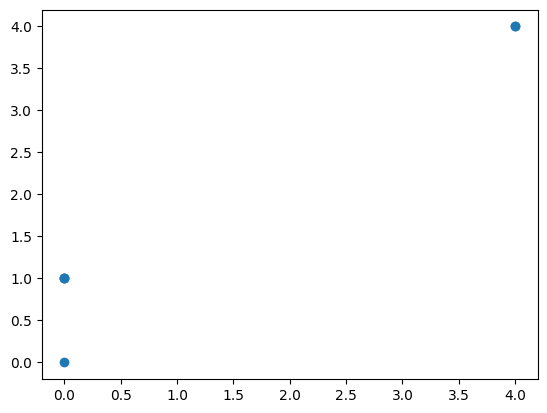

In [ ]:
from coverage_planner.env import GridWorld, Agent
from coverage_planner.objective import Coverage
from coverage_planner.policies.tools import path_model
from coverage_planner.policies.centralized import best_seq_greedy_solve
from coverage_planner.policies.sequential import seq_greedy_solve, split_seq_solve

STEPS = 3
NUM_AGENTS = 3
AGENT_ORDER = [1,2,3]
SPLIT_CHUNKSIZE = 2
WORLD_SIZE = 5

def init_world(size: int):
    grid = GridWorld(size)

    agent_1 = Agent(0,0)
    agent_2 = Agent(grid.size-1,0)
    agent_3 = Agent(0,grid.size-1)
    agent_4 = Agent(grid.size-1,grid.size-1)
    agents = [agent_1, agent_2, agent_3,agent_4]
    grid.init_agent(agents[:NUM_AGENTS])
    print(grid)
    return grid

grid = init_world(WORLD_SIZE)
model = path_model(grid,Coverage,steps=STEPS,agent_order=AGENT_ORDER)
score_seq = seq_greedy_solve(model)
assert score_seq == grid.get_score()
print(f"Sequential:\n{grid}")
grid.reset_grid()

score_split = split_seq_solve(grid, Coverage, steps=STEPS,agent_order=AGENT_ORDER, chunksize=SPLIT_CHUNKSIZE)
assert score_split == grid.get_score()
print(f"Split-Sequential:\n{grid}")
grid.reset_grid()

model = path_model(grid,Coverage,steps=STEPS)
score_opt, agent_order = best_seq_greedy_solve(model)
assert score_opt == grid.get_score()

print(f"Optimal:\n{grid}")



print(f"Sequential Score: {score_seq}")
print(f"Split Score: {score_split}")
print(f"Optimal Score: {score_opt}")
print(f"Seq/Opt Ratio: {score_seq/score_opt*100}%")
grid.plot()

In [17]:
grid.print_paths()
for agent in grid.agents:
    print(agent.path)
    print(agent.path[:][:][0])


Agent paths: 
  1: (0, 0)->(1, 0)->(2, 0)->(3, 0)
  2: (4, 0)->(4, 1)->(4, 2)->(4, 3)
  3: (0, 4)->(1, 4)->(2, 4)->(3, 4)
[(0, 0), (1, 0), (2, 0), (3, 0)]
(0, 0)
[(4, 0), (4, 1), (4, 2), (4, 3)]
(4, 0)
[(0, 4), (1, 4), (2, 4), (3, 4)]
(0, 4)


# Objective:
$$\max(\bigcup_{i\in\text{agents}}\text{Coverage}_i)$$